# Identificación de variables críticas de proceso — SECOM (fabricación de semiconductores)

**Autora:** Sara Gambandé

## Contexto
El dataset **SECOM** (UCI Machine Learning Repository) contiene mediciones reales de **590 sensores y puntos de control** de una línea
de fabricación de semiconductores, registradas entre julio y octubre de 2008. Cada fila es un lote producido y la etiqueta indica si
pasó (`-1`) o falló (`1`) la prueba de calidad final.

## Objetivo
Responder a la pregunta típica de un equipo de Operaciones / Calidad:

> **¿Qué variables de proceso están asociadas a las fallas de calidad, y qué tan confiable es esa conclusión?**

## Enfoque
1. **Calidad de datos:** depuración y estandarización de variables de sensores (faltantes, constantes, redundantes).
2. **Tendencia de desempeño:** evolución temporal de la tasa de fallas.
3. **Pruebas de hipótesis:** comparación pasa vs. falla para cada variable, con corrección por comparaciones múltiples.
4. **Correlación:** detección de variables redundantes entre las críticas.
5. **PCA:** estructura de la variabilidad del proceso.
6. **Regresión logística (Statsmodels):** cuantificación del efecto de las variables críticas.
7. **Validación del modelo:** validación cruzada y comparación contra un baseline, para *desafiar* el resultado.
8. **Recomendaciones** y propuesta de **Diseño de Experimentos (DoE)** para confirmar causalidad.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier

PASA, FALLA = "#2a78d6", "#eb6834"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Carga y calidad de datos

In [2]:
df = pd.read_csv("data/uci-secom.csv")
df = df.rename(columns={"Time": "fecha", "Pass/Fail": "resultado"})

# Corrección de fechas: en esta versión del CSV, las fechas con día <= 12 quedaron con día y mes invertidos
# (ej. "2008-01-08" es en realidad 8 de agosto). Se detectó porque la serie no era cronológica y aparecían
# meses fuera del período documentado (jul-oct 2008).
fecha = pd.to_datetime(df["fecha"])
ambiguas = fecha.dt.day <= 12
fecha[ambiguas] = fecha[ambiguas].apply(lambda x: x.replace(month=x.day, day=x.month))
assert fecha.is_monotonic_increasing, "Las fechas siguen desordenadas"
df["fecha"] = fecha
print(f"Fechas corregidas: {ambiguas.sum()} de {len(df)}")
sensores = [c for c in df.columns if c not in ("fecha", "resultado", "falla")]
df = df.rename(columns={c: f"s{c}" for c in sensores}).copy()
sensores = [f"s{c}" for c in sensores]
df["falla"] = (df["resultado"] == 1).astype(int)

print(f"Lotes: {len(df):,} | Variables de proceso: {len(sensores)}")
print(f"Período: {df.fecha.min():%d/%m/%Y} a {df.fecha.max():%d/%m/%Y}")
print(f"Tasa de fallas: {df.falla.mean():.1%} ({df.falla.sum()} lotes)")

Fechas corregidas: 604 de 1567
Lotes: 1,567 | Variables de proceso: 590
Período: 19/07/2008 a 17/10/2008
Tasa de fallas: 6.6% (104 lotes)


In [3]:
X = df[sensores]
faltantes = X.isna().mean()
constantes = X.nunique(dropna=True) <= 1

reporte = pd.Series({
    "Variables originales": len(sensores),
    "Con >50% de faltantes (eliminadas)": int((faltantes > 0.5).sum()),
    "Constantes / sin variación (eliminadas)": int((constantes & (faltantes <= 0.5)).sum()),
})
utiles = [c for c in sensores if faltantes[c] <= 0.5 and not constantes[c]]
reporte["Variables útiles"] = len(utiles)
print(reporte.to_string())
print(f"\nFaltantes restantes: {X[utiles].isna().mean().mean():.2%} de las celdas -> se imputan con la mediana")

X = X[utiles].fillna(X[utiles].median())
y = df["falla"]

Variables originales                       590
Con >50% de faltantes (eliminadas)          28
Constantes / sin variación (eliminadas)    116
Variables útiles                           446

Faltantes restantes: 1.56% de las celdas -> se imputan con la mediana


> **Decisión:** se imputa con la **mediana** (robusta a outliers, frecuentes en datos de sensores). En un entorno real,
> antes de imputar habría que consultar con planta *por qué* falta el dato (sensor caído, variable no aplicable a ese producto, etc.).

## 2. Tendencia de desempeño: tasa de fallas en el tiempo

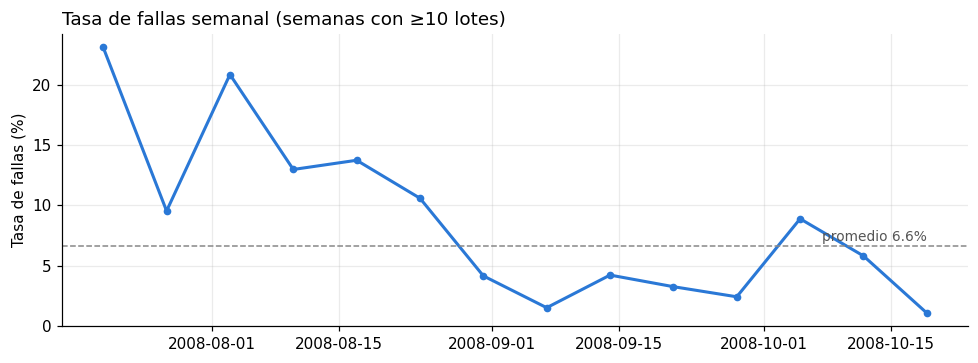

In [4]:
semanal = df.set_index("fecha").resample("W")["falla"].agg(["mean", "count"]).rename(
    columns={"mean": "tasa_fallas", "count": "lotes"})
semanal = semanal[semanal.lotes >= 10]

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(semanal.index, semanal.tasa_fallas * 100, color=PASA, lw=2, marker="o", ms=4)
ax.axhline(y.mean() * 100, color="#888", ls="--", lw=1)
ax.text(semanal.index[-1], y.mean() * 100 + 0.4, f"promedio {y.mean():.1%}", ha="right", color="#555", fontsize=9)
ax.set_ylabel("Tasa de fallas (%)")
ax.set_title("Tasa de fallas semanal (semanas con ≥10 lotes)", loc="left")
plt.tight_layout(); plt.show()

In [5]:
# ¿La tasa de fallas cambió entre la primera y la segunda mitad del período? (prueba chi-cuadrado)
mitad = df.fecha.median()
tabla = pd.crosstab(df.fecha < mitad, df.falla)
chi2, p, _, _ = stats.chi2_contingency(tabla)
print(f"Tasa 1ª mitad: {df[df.fecha < mitad].falla.mean():.1%} | 2ª mitad: {df[df.fecha >= mitad].falla.mean():.1%}")
print(f"Chi-cuadrado p-valor = {p:.4f}")

Tasa 1ª mitad: 8.6% | 2ª mitad: 4.7%
Chi-cuadrado p-valor = 0.0032
